# Train Model PM2.5, PM10, CO — Prophet (Optimized)

Prophet tanpa feature engineering lag/rolling.  
Menggunakan kekuatan internal Prophet:
- Extra regressors (temperature, humidity, NO₂, O₃)
- Custom daily seasonality (Fourier order tinggi)
- Changepoint detection

In [17]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from supabase import create_client, Client
import os
from datetime import datetime, timedelta
import joblib
import warnings
warnings.filterwarnings('ignore')

SUPABASE_URL = os.getenv("SUPABASE_URL", "")
SUPABASE_KEY = os.getenv("SUPABASE_KEY", "")

if not SUPABASE_URL or not SUPABASE_KEY:
    env_path = ".env"
    if os.path.exists(env_path):
        for line in open(env_path):
            if "=" in line and not line.startswith("#"):
                k, _, v = line.partition("=")
                os.environ[k.strip()] = v.strip().strip('"')
    SUPABASE_URL = os.getenv("SUPABASE_URL", "")
    SUPABASE_KEY = os.getenv("SUPABASE_KEY", "")

SUPABASE_URL = SUPABASE_URL.replace("http://", "https://")
supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)
print(f"Connected to {SUPABASE_URL}")

Connected to https://knpwncirbhcytssrxcqx.supabase.co


### 1. Ambil Data (7 hari)

In [18]:
TABLE = "tb_konsentrasi_gas"
days_back = 30
since = (datetime.now() - timedelta(days=days_back)).isoformat()

all_data = []
offset = 0
while True:
    resp = supabase.table(TABLE) \
        .select("pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3,temperature,humidity,created_at") \
        .gte("created_at", since) \
        .order("created_at", desc=False) \
        .range(offset, offset + 999) \
        .execute()
    batch = resp.data
    if not batch:
        break
    all_data.extend(batch)
    offset += len(batch)

df = pd.DataFrame(all_data)
for col in ["pm25_ugm3","pm10_ugm3","co_ugm3","no2_ugm3","o3_ugm3","temperature","humidity"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["created_at"] = pd.to_datetime(df["created_at"]).dt.tz_localize(None)
df = df.dropna(subset=["pm25_ugm3","pm10_ugm3","co_ugm3"])
df = df.set_index("created_at").sort_index()
df = df[~df.index.duplicated(keep="first")]

# Isi NaN extra regressors
for col in ["temperature", "humidity", "no2_ugm3", "o3_ugm3"]:
    df[col] = df[col].ffill().bfill()

print(f"Total: {len(df)} baris")
print(f"Rentang: {df.index[0]} - {df.index[-1]}")
print(f"PM2.5: mean={df['pm25_ugm3'].mean():.1f}, std={df['pm25_ugm3'].std():.1f}")
print(f"PM10:  mean={df['pm10_ugm3'].mean():.1f}, std={df['pm10_ugm3'].std():.1f}")
print(f"CO:    mean={df['co_ugm3'].mean():.1f}, std={df['co_ugm3'].std():.1f}")

Total: 27909 baris
Rentang: 2026-05-15 16:26:14.627359 - 2026-06-13 02:12:36.016918
PM2.5: mean=16.1, std=3.1
PM10:  mean=17.9, std=4.3
CO:    mean=2923.0, std=493.7


### 2. EDA & Uji Stasioneritas

In [19]:
print("=== RINGKASAN STATISTIK ===")
print(df.describe().round(2))
print(f"\nRentang waktu: {df.index[0]} - {df.index[-1]}")
print(f"Total baris: {len(df)}")
print(f"Missing: {df.isnull().sum().sum()}")

=== RINGKASAN STATISTIK ===
       pm25_ugm3  pm10_ugm3   co_ugm3  no2_ugm3   o3_ugm3  temperature  \
count   27909.00   27909.00  27909.00  27909.00  27909.00     27909.00   
mean       16.06      17.94   2922.97      0.11     22.47        34.69   
std         3.07       4.31    493.74      5.75     15.72         2.04   
min         8.02       7.71    918.37      0.00      1.08        29.60   
25%        14.18      15.38   2610.66      0.00     19.63        33.50   
50%        15.42      17.23   2928.03      0.00     19.63        34.60   
75%        17.36      19.56   3244.52      0.00     19.63        34.90   
max       141.25     242.34   8237.73    309.59    140.42        47.60   

       humidity  
count  27909.00  
mean      59.80  
std        7.79  
min       26.40  
25%       56.40  
50%       61.20  
75%       65.30  
max       98.00  

Rentang waktu: 2026-05-15 16:26:14.627359 - 2026-06-13 02:12:36.016918
Total baris: 27909
Missing: 0


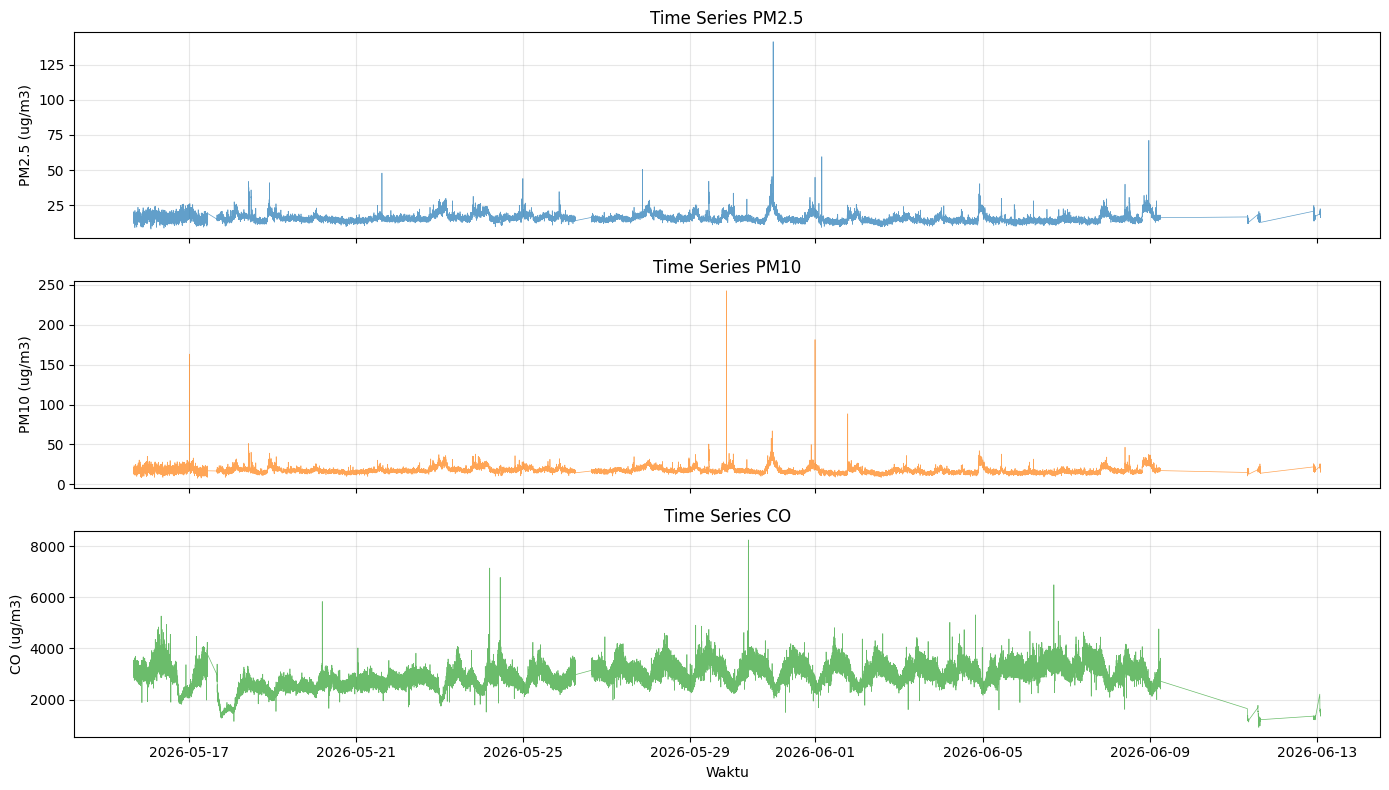

In [20]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df.index, df["pm25_ugm3"], color="tab:blue", alpha=0.7, linewidth=0.5)
axes[0].set_ylabel("PM2.5 (ug/m3)") ; axes[0].set_title("Time Series PM2.5") ; axes[0].grid(alpha=0.3)
axes[1].plot(df.index, df["pm10_ugm3"], color="tab:orange", alpha=0.7, linewidth=0.5)
axes[1].set_ylabel("PM10 (ug/m3)") ; axes[1].set_title("Time Series PM10") ; axes[1].grid(alpha=0.3)
axes[2].plot(df.index, df["co_ugm3"], color="tab:green", alpha=0.7, linewidth=0.5)
axes[2].set_ylabel("CO (ug/m3)") ; axes[2].set_title("Time Series CO") ; axes[2].grid(alpha=0.3)
plt.xlabel("Waktu") ; plt.tight_layout() ; plt.show()

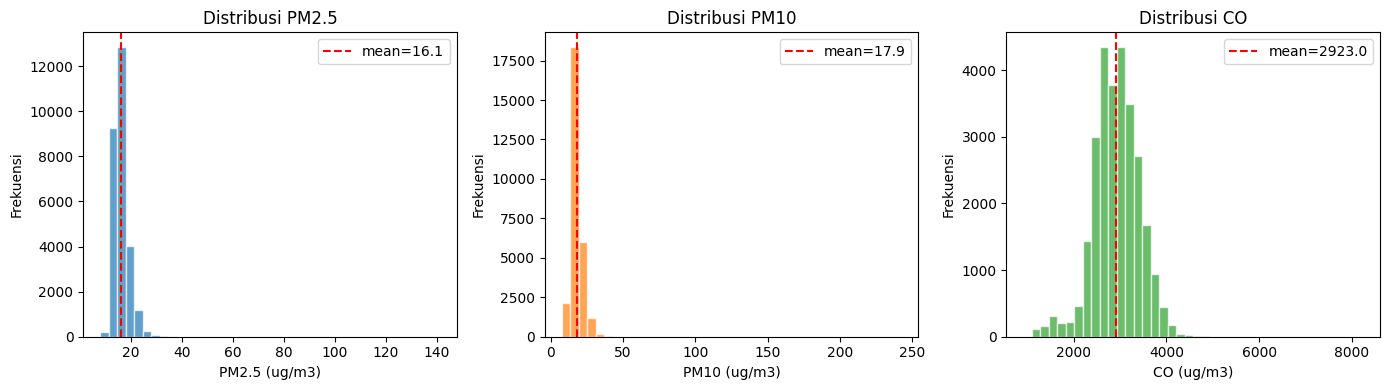

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color, title in zip(axes, ["pm25_ugm3","pm10_ugm3","co_ugm3"], ["tab:blue","tab:orange","tab:green"], ["PM2.5","PM10","CO"]):
    vals = df[col].dropna()
    ax.hist(vals, bins=40, color=color, edgecolor="white", alpha=0.7)
    ax.set_xlabel(f"{title} (ug/m3)") ; ax.set_ylabel("Frekuensi")
    ax.set_title(f"Distribusi {title}")
    ax.axvline(vals.mean(), color="red", ls="--", label=f"mean={vals.mean():.1f}")
    ax.legend()
plt.tight_layout() ; plt.show()

In [22]:
from statsmodels.tsa.stattools import adfuller
print("=== UJI STASIONERITAS (ADF) ===\n")
for col in ["pm25_ugm3", "pm10_ugm3", "co_ugm3"]:
    stat, pval, usedlag, nobs, crit, icbest = adfuller(df[col].dropna())
    msg = "STASIONER" if pval < 0.05 else "TIDAK STASIONER"
    print(f"{col:12s} | ADF={stat:.4f} | p-value={pval:.6f} | {msg}")

=== UJI STASIONERITAS (ADF) ===

pm25_ugm3    | ADF=-7.5723 | p-value=0.000000 | STASIONER
pm10_ugm3    | ADF=-8.1997 | p-value=0.000000 | STASIONER
co_ugm3      | ADF=-4.6143 | p-value=0.000122 | STASIONER


### 3. Prophet

Extra regressors: temperature, humidity, NO₂, O₃  
Custom seasonality: hourly (period=60, Fourier order=10) + daily_seasonality  
Tanpa lag/rolling features.

In [23]:
TARGETS = ["pm25_ugm3", "pm10_ugm3", "co_ugm3"]
ALIAS = {"pm25_ugm3": "PM2.5", "pm10_ugm3": "PM10", "co_ugm3": "CO"}
PKL_MAP = {"pm25_ugm3": "prophet_pm25.pkl", "pm10_ugm3": "prophet_pm10.pkl", "co_ugm3": "prophet_co.pkl"}
EXTRA_REGS = ["temperature", "humidity", "no2_ugm3", "o3_ugm3"]
horizon = 60

results = {}

In [24]:
def build_prophet(changepoint_prior_scale=0.05):
    m = Prophet(
        weekly_seasonality=False,
        daily_seasonality=True,
        seasonality_mode='additive',
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=10,
        changepoint_range=0.9,
        uncertainty_samples=0,
    )
    m.add_seasonality(name="hourly", period=60, fourier_order=10)
    for reg in EXTRA_REGS:
        m.add_regressor(reg)
    return m


for target in TARGETS:
    print(f"\n{'='*60}")
    print(f"Prophet — {ALIAS[target]}")
    print(f"{'='*60}")
    
    prophet_df = df[[target]].reset_index()
    prophet_df.columns = ["ds", "y"]
    extra_df = df[EXTRA_REGS].reset_index(drop=True)
    
    total = len(prophet_df)
    split_idx = int(total * 0.8) - (int(total * 0.8) % horizon)
    
    train = prophet_df.iloc[:split_idx]
    train_extra = extra_df.iloc[:split_idx]
    test = prophet_df.iloc[split_idx:split_idx + horizon]
    test_extra = extra_df.iloc[split_idx:split_idx + horizon]
    
    # Quick grid: coba 3 nilai changepoint_prior
    best_cps = 0.05
    best_mae = np.inf
    for cps in [0.01, 0.05, 0.1]:
        m = build_prophet(cps)
        train_full = train.copy()
        for reg in EXTRA_REGS:
            train_full[reg] = train_extra[reg].values
        try:
            m.fit(train_full)
        except:
            continue
        
        future = m.make_future_dataframe(periods=horizon, freq="min")
        for reg in EXTRA_REGS:
            future[reg] = np.concatenate([train_extra[reg].values, test_extra[reg].values])[:len(future)]
        
        forecast = m.predict(future)
        y_pred = np.maximum(forecast["yhat"].iloc[-horizon:].values, 0)
        y_true = test["y"].values
        mae = mean_absolute_error(y_true, y_pred)
        print(f"  cps={cps} -> MAE={mae:.4f}")
        if mae < best_mae:
            best_mae = mae
            best_cps = cps
    
    # Final model with best cps
    print(f"  Training final (cps={best_cps})...")
    m = build_prophet(best_cps)
    train_full = prophet_df.copy()
    for reg in EXTRA_REGS:
        train_full[reg] = extra_df[reg].values
    m.fit(train_full)
    m.stan_backend.logger = None
    joblib.dump(m, PKL_MAP[target])
    
    # Eval on test set
    future = m.make_future_dataframe(periods=horizon, freq="min")
    for reg in EXTRA_REGS:
        future[reg] = np.concatenate([extra_df[reg].values, test_extra[reg].values])[:len(future)]
    
    forecast = m.predict(future)
    y_pred = np.maximum(forecast["yhat"].iloc[-horizon:].values, 0)
    y_true = test["y"].values
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    results[target] = {
        "pkl": PKL_MAP[target], "mae": round(mae, 4),
        "rmse": round(rmse, 4), "r2": round(r2, 4),
        "best_cps": best_cps,
    }
    
    print(f"  HASIL AKHIR — MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f} ({r2*100:.2f}%)")

print(f"\n{'='*60}")
print("RINGKASAN PROPHET")
print(f"{'='*60}")
for name, r in results.items():
    print(f"  {ALIAS[name]:6s} | R2={r['r2']:.4f} ({r['r2']*100:.1f}%) | MAE={r['mae']:.4f} | RMSE={r['rmse']:.4f} | cps={r['best_cps']}")


Prophet — PM2.5


16:25:53 - cmdstanpy - INFO - Chain [1] start processing
16:26:04 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.01 -> MAE=1.0617


16:26:05 - cmdstanpy - INFO - Chain [1] start processing
16:26:24 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.05 -> MAE=1.2087


...

  cps=0.05 -> MAE=187.1820


16:28:34 - cmdstanpy - INFO - Chain [1] start processing
16:29:07 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.1 -> MAE=187.4184
  Training final (cps=0.05)...


16:29:09 - cmdstanpy - INFO - Chain [1] start processing
16:29:38 - cmdstanpy - INFO - Chain [1] done processing


  HASIL AKHIR — MAE=1696.0115, RMSE=1710.4162, R2=-59.6222 (-5962.22%)

RINGKASAN PROPHET
  PM2.5  | R2=-1.7878 (-178.8%) | MAE=1.3672 | RMSE=1.6257 | cps=0.01
  PM10   | R2=-1.2633 (-126.3%) | MAE=1.5596 | RMSE=1.8812 | cps=0.01
  CO     | R2=-59.6222 (-5962.2%) | MAE=1696.0115 | RMSE=1710.4162 | cps=0.05


### 4. Quick Test Prediksi 60 Menit ke Depan

In [25]:
last_time = df.index[-1]
print("Nilai aktual terakhir:\n")
for target in TARGETS:
    print(f"  {ALIAS[target]:6s} : {df[target].iloc[-1]:.1f}")

print("\n" + "="*60)
print("Prediksi 60 menit ke depan — Prophet")
print("="*60)

for target in TARGETS:
    model = joblib.load(PKL_MAP[target])
    future = pd.DataFrame({"ds": pd.date_range(start=last_time + timedelta(minutes=1), periods=60, freq="min")})
    for reg in EXTRA_REGS:
        future[reg] = df[reg].iloc[-1]
    fc = model.predict(future)
    preds = np.maximum(fc["yhat"].values, 0)
    print(f"\n  {ALIAS[target]}:")
    print(f"    Aktual terakhir: {df[target].iloc[-1]:.1f}")
    print(f"    1 menit  : {preds[0]:.1f}")
    print(f"    15 menit : {preds[14]:.1f}")
    print(f"    30 menit : {preds[29]:.1f}")
    print(f"    60 menit : {preds[-1]:.1f}")

Nilai aktual terakhir:

  PM2.5  : 19.3
  PM10   : 19.3
  CO     : 1354.5

Prediksi 60 menit ke depan — Prophet

  PM2.5:
    Aktual terakhir: 19.3
    1 menit  : 17.2
    15 menit : 17.1
    30 menit : 17.1
    60 menit : 16.9

  PM10:
    Aktual terakhir: 19.3
    1 menit  : 19.1
    15 menit : 18.9
    30 menit : 18.8
    60 menit : 18.5

  CO:
    Aktual terakhir: 1354.5
    1 menit  : 1616.2
    15 menit : 1684.0
    30 menit : 1759.7
    60 menit : 1915.8


### 5. Plot Forecast vs Aktual

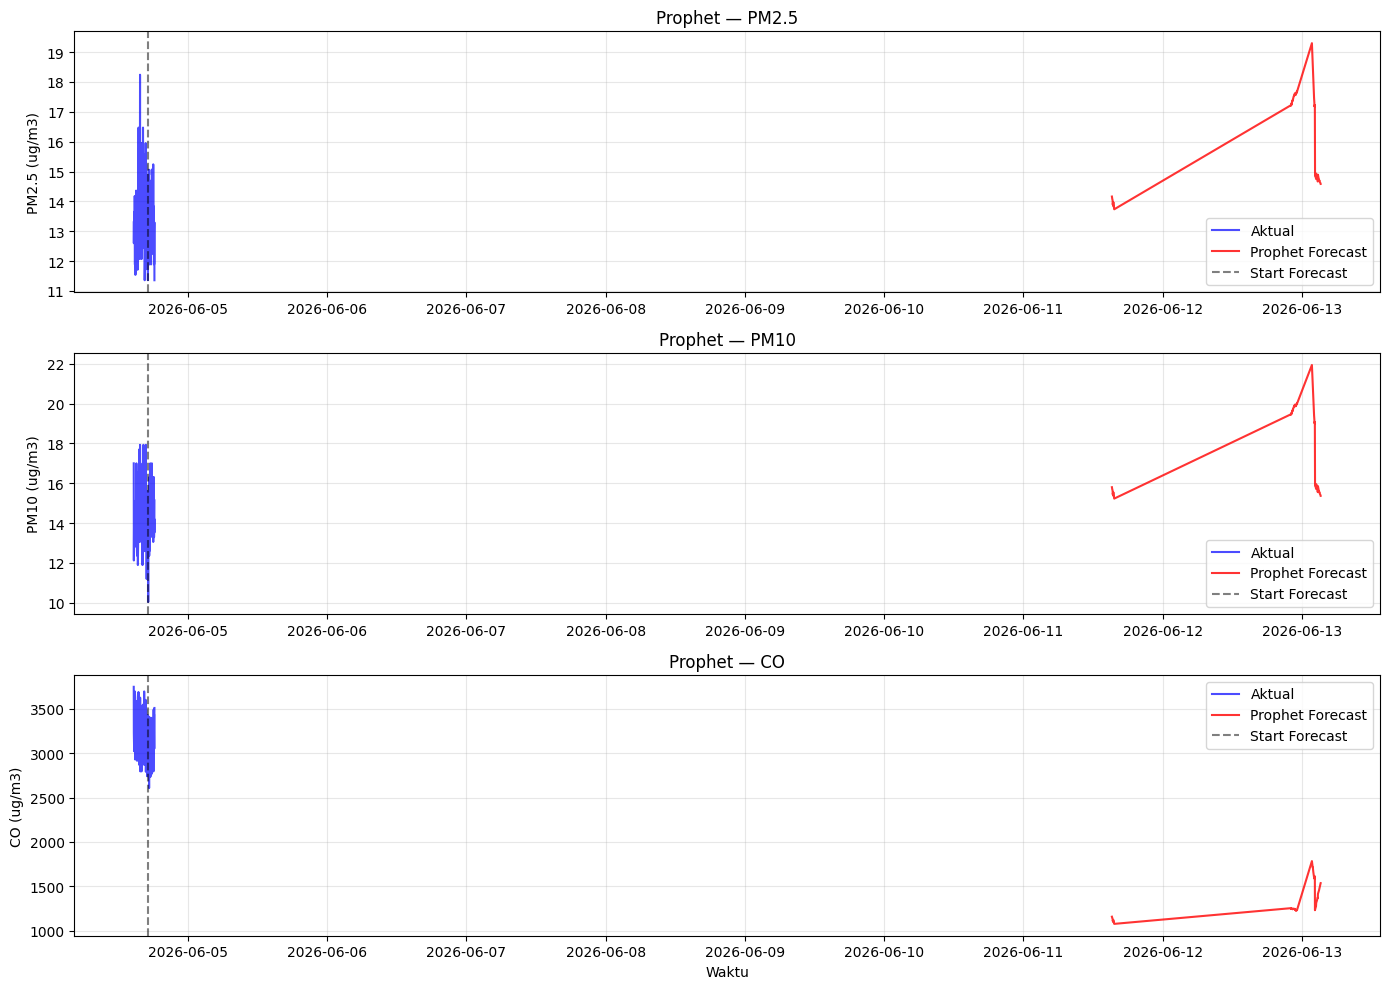

PM2.5  | R2=-1.7878 | MAE=1.3672 | RMSE=1.6257
PM10   | R2=-1.2633 | MAE=1.5596 | RMSE=1.8812
CO     | R2=-59.6222 | MAE=1696.0115 | RMSE=1710.4162


In [26]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, target in zip(axes, TARGETS):
    model = joblib.load(PKL_MAP[target])
    prophet_df = df[[target]].reset_index()
    prophet_df.columns = ["ds", "y"]
    extra_df = df[EXTRA_REGS].reset_index(drop=True)
    total = len(prophet_df)
    split_idx = int(total * 0.8) - (int(total * 0.8) % 60)
    
    future = model.make_future_dataframe(periods=60, freq="min")
    for reg in EXTRA_REGS:
        reg_values = np.concatenate([extra_df[reg].values, extra_df[reg].iloc[split_idx:split_idx+60].values])
        future[reg] = reg_values[:len(future)]
    
    forecast = model.predict(future)
    fc_test = forecast.iloc[-(60 + 120):]
    test_df = prophet_df.iloc[split_idx-120:split_idx+60]
    
    ax.plot(test_df["ds"], test_df["y"], label="Aktual", color="blue", alpha=0.7)
    ax.plot(fc_test["ds"], fc_test["yhat"], label="Prophet Forecast", color="red", alpha=0.8)
    ax.axvline(x=test_df["ds"].iloc[120], color="black", ls="--", alpha=0.5, label="Start Forecast")
    ax.set_ylabel(f"{ALIAS[target]} (ug/m3)")
    ax.set_title(f"Prophet — {ALIAS[target]}")
    ax.legend() ; ax.grid(alpha=0.3)

plt.xlabel("Waktu") ; plt.tight_layout() ; plt.show()

for target in TARGETS:
    r = results[target]
    print(f"{ALIAS[target]:6s} | R2={r['r2']:.4f} | MAE={r['mae']:.4f} | RMSE={r['rmse']:.4f}")